[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_17/MFM_ch17_seminar/MFM_ch17_seminar.ipynb)

# Modelling Financial Markets — Seminar 17: Bubbles and Crashes

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: derivations (A1–A8); Part B: estimation and inference (B1–B10); Part C: C1 is there an AI bubble?, C2 critique of an AI answer, C3 volume and prices in a speculative boom.

> Quantlet `MFM_ch17_seminar`: student version of the Seminar 17 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5, B7, B9) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, B8, B10, C1, C2, C3) are not solved here (an empty code cell where they need code).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_17'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
# On Colab: !pip install xlrd
import io
import json
import os
import re
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import optimize, stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'

HERE = '.'
SEED = 42
R_MC = 2000
# Computing the confidence indicator takes several minutes; set RECOMPUTE = True to recompute it, otherwise precomputed values are used.
RECOMPUTE = False
QL_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_17/'


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend(fig, axes, ncol=3, y=0.0):
    """One legend for a multi-panel figure, below the figure."""
    h, l = [], []
    for ax in np.atleast_1d(axes):
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l and not ll.startswith('_'):
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer, np.bool_)):
        return o.item()
    if isinstance(o, pd.Timestamp):
        return str(o.date())
    return o


def yrs(idx):
    """Date -> decimal years."""
    idx = pd.DatetimeIndex(idx)
    return np.asarray(idx.year + (idx.dayofyear - 1) / 365.25)


def todate(x):
    """Ani zecimali -> data."""
    y = int(np.floor(x))
    return pd.Timestamp(f'{y}-01-01') + pd.Timedelta(days=float((x - y) * 365.25))


def d2s(d):
    return None if d is None else str(pd.Timestamp(d).date())


import shutil
import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder
# precomputed LPPLS confidence indicators
for _d in ('.', os.path.join('..', 'Quantlets', 'Ch_17'), os.path.join('..', '..', 'Quantlets', 'Ch_17')):
    for _f in ('ch17_lppls_ci_btc.csv', 'ch17_lppls_ci_ndx.csv'):
        if os.path.exists(os.path.join(_d, _f)) and not os.path.exists(os.path.join(HERE, _f)):
            shutil.copy(os.path.join(_d, _f), HERE)


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026 (Nasdaq 100, S&P 500, BET, BET-FI, Bitcoin, Ethereum, Dogecoin, NVIDIA, Cisco, Tesla, GameStop, Strategy (formerly MicroStrategy)).
- Weekly and monthly series: last close of the week or month; stocks adjusted for dividends and splits.
- S&P Composite monthly since 1871 (Robert J. Shiller); 49 US industry portfolios (Kenneth French Data Library), of which Greenwood, Shleifer and You (2019, *Bubbles for Fama*) use the first 48.
- The last, incomplete week or month is dated at its last observation (18 September 2026).

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# read the course data
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, type, price field, start date)
MARKETS = {
    'sp500': ('GSPC.INDX',   'S&P 500',        'index',  'close',          '1990-01-01'),
    'ndx':   ('NDX.INDX',    'Nasdaq 100',     'index',  'close',          '1990-01-01'),
    'bet':   ('BET',         'BET',            'index',  'close',          '1997-09-19'),
    'betfi': ('BETFI.INDX',  'BET-FI',         'index',  'close',          '2012-01-25'),
    'btc':   ('BTC-USD.CC',  'Bitcoin',        'crypto', 'close',          '2014-09-17'),
    'eth':   ('ETH-USD.CC',  'Ethereum',       'crypto', 'close',          '2016-01-01'),
    'doge':  ('DOGE-USD.CC', 'Dogecoin',       'crypto', 'close',          '2017-01-01'),
    'nvda':  ('NVDA.US',     'NVIDIA',         'stock',  'adjusted_close', '1999-01-22'),
    'csco':  ('CSCO.US',     'Cisco Systems',  'stock',  'adjusted_close', '1990-02-16'),
    'tsla':  ('TSLA.US',     'Tesla',          'stock',  'adjusted_close', '2010-06-29'),
    'gme':   ('GME.US',      'GameStop',       'stock',  'adjusted_close', '2002-02-13'),
    'mstr':  ('MSTR.US',     'Strategy (MicroStrategy)', 'stock', 'adjusted_close', '1998-06-11'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

SHILLER_URLS = ['https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/ie_data.xls',
                'http://www.econ.yale.edu/~shiller/data/ie_data.xls']
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'

_CACHE = {}


def read_market(symbol):
    """Read the daily prices of one asset from the course data."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(name, freq='D', start=None, end=END):
    """Price level: 'D' daily (cleaned), 'W' last price of the week, 'M' last price of the month."""
    symbol, _, kind, col, start0 = MARKETS[name]
    s = read_market(symbol)[col].loc[start or start0:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
    if kind == 'index':
        s = s[s.diff() != 0]                  # drop holidays filled with the previous price
    last = s.index[-1]
    if freq == 'W':
        s = s.resample('W-FRI').last().dropna()
    elif freq == 'M':
        s = s.resample('ME').last().dropna()
    if freq in ('W', 'M') and s.index[-1] > last:
        s.index = s.index[:-1].append(pd.DatetimeIndex([last]))   # last incomplete period: dated at its last observation
    return s.rename(name)


def shiller_urls():
    """Addresses of Shiller's ie_data.xls: the current shillerdata.com link, then known copies."""
    urls = []
    try:
        html = urllib.request.urlopen(urllib.request.Request('https://shillerdata.com/', headers={'User-Agent': 'Mozilla/5.0'}),
                                      timeout=60).read().decode('utf-8', 'ignore')
        urls += ['https:' + u if u.startswith('//') else u
                 for u in re.findall(r'href="([^"]*ie_data\.xls[^"]*)"', html)]
    except Exception:
        pass
    return urls + SHILLER_URLS


def shiller():
    """Monthly S&P Composite (Shiller): real price, real dividend and the price-dividend ratio (P/D)."""
    if 'shiller' in _CACHE:
        return _CACHE['shiller']
    raw = None
    for url in shiller_urls():
        try:
            raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                         timeout=120).read()
            break
        except Exception:
            continue
    d = pd.read_excel(io.BytesIO(raw), sheet_name='Data', header=None, skiprows=8)
    d = d.iloc[:, [0, 1, 2, 7, 8]]
    d.columns = ['date', 'P', 'D', 'real_P', 'real_D']
    d = d[pd.to_numeric(d['date'], errors='coerce').notna()].copy()
    yr = d['date'].astype(float)
    year = np.floor(yr + 1e-9).astype(int)
    month = np.round((yr - year) * 100).astype(int)
    d.index = pd.to_datetime(dict(year=year, month=month, day=1)) + pd.offsets.MonthEnd(0)
    d = d[['P', 'D', 'real_P', 'real_D']].apply(pd.to_numeric, errors='coerce').dropna()
    d['PD'] = d['real_P'] / d['real_D']
    _CACHE['shiller'] = d
    return d


def _french_table(fname, section=None, scale=100.0):
    """One monthly table (YYYYMM) from a Kenneth French file: the first (default) or the one titled `section`;
    returns are divided by `scale` (100: decimal), firm counts are read with scale=1."""
    raw = urllib.request.urlopen(urllib.request.Request(FRENCH + fname, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    text = zipfile.ZipFile(io.BytesIO(raw)).read(zipfile.ZipFile(io.BytesIO(raw)).namelist()[0]).decode('latin-1')
    lines = text.splitlines()
    k0 = 0 if section is None else next(k for k, l in enumerate(lines) if l.strip() == section)
    i = next(k for k, l in enumerate(lines) if k >= k0 and l.startswith(',') and len(l.split(',')) > 1)
    cols = [c.strip() for c in lines[i].split(',')[1:]]
    rows = []
    for l in lines[i + 1:]:
        parts = [x.strip() for x in l.split(',')]
        if not parts or len(parts[0]) != 6 or not parts[0].isdigit():
            break
        rows.append([parts[0]] + [float(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=['date'] + cols)
    df['date'] = pd.to_datetime(df['date'], format='%Y%m') + pd.offsets.MonthEnd(0)
    return df.set_index('date').replace([-99.99, -999.0], np.nan) / scale


def industries():
    """49 industries (value-weighted monthly returns) and the market return (Mkt-RF + RF)."""
    if 'ind' in _CACHE:
        return _CACHE['ind']
    ind = _french_table('49_Industry_Portfolios_CSV.zip')
    ff = _french_table('F-F_Research_Data_Factors_CSV.zip')
    mkt = (ff['Mkt-RF'] + ff['RF']).rename('MKT')
    _CACHE['ind'] = (ind, mkt)
    return ind, mkt


def industry_firms():
    """Monthly number of firms in each of the 49 industry portfolios (Kenneth French)."""
    if 'firms' not in _CACHE:
        _CACHE['firms'] = _french_table('49_Industry_Portfolios_CSV.zip', 'Number of Firms in Portfolios', 1.0)
    return _CACHE['firms']

## Explosiveness tests, LPPLS and drawdowns

- Functions for the right-tailed augmented Dickey–Fuller (ADF) test, its supremum (SADF) and generalized supremum (GSADF) versions, the backward SADF sequence (BSADF), Monte Carlo and wild bootstrap critical values, and date-stamping.
- Functions for the log-periodic power law singularity (LPPLS) model: calibration (Filimonov–Sornette), filter and confidence indicator.

In [ ]:
def _cums(y):
    """Cumulative sums for the regression Delta y_t = a + b y_{t-1} (rows t = 1..n); y may be (n+1,) or (R, n+1)."""
    y = np.atleast_2d(np.asarray(y, float))
    x, z = y[:, :-1], np.diff(y, axis=1)
    pad = lambda a: np.concatenate([np.zeros((a.shape[0], 1)), np.cumsum(a, axis=1)], axis=1)
    return pad(x), pad(x * x), pad(z), pad(z * z), pad(x * z)


def _adf_end(C, e, s):
    """t-statistic of b for the windows [s, e] (s a vector), over all replications (rows of C)."""
    Sx, Sxx, Sz, Szz, Sxz = (c[:, e + 1][:, None] - c[:, s] for c in C)
    n = (e + 1 - s).astype(float)
    den = n * Sxx - Sx ** 2
    b = (n * Sxz - Sx * Sz) / den
    a = (Sz - b * Sx) / n
    ssr = np.maximum(Szz - a * Sz - b * Sxz, 1e-300)
    return b / np.sqrt(ssr / (n - 2) * n / den)


def adf_stat(y):
    """Right-tailed ADF on the whole series (no lags)."""
    C = _cums(y)
    n = len(y) - 1
    return float(_adf_end(C, n - 1, np.array([0]))[0, 0])


def min_window(T, r0=None):
    """Fereastra minima PSY: r0 = 0.01 + 1.8 / sqrt(T)."""
    r0 = 0.01 + 1.8 / np.sqrt(T) if r0 is None else r0
    return int(np.floor(r0 * T)), r0


def psy(y, r0=None):
    """ADF, SADF, GSADF and the BSADF (sup over start points) and recursive ADF (PWY) sequences for y (log level)."""
    y = np.asarray(y, float)
    n = len(y) - 1                                  # number of regression rows
    w0, r0 = min_window(n, r0)
    C = _cums(y)
    bsadf = np.full(n, np.nan)
    fwd = np.full(n, np.nan)
    for e in range(w0 - 1, n):
        s = np.arange(0, e - w0 + 2)
        st = _adf_end(C, e, s)[0]
        bsadf[e] = st.max()
        fwd[e] = st[0]
    return dict(adf=float(fwd[-1]), sadf=float(np.nanmax(fwd)), gsadf=float(np.nanmax(bsadf)),
                bsadf=bsadf, fwd=fwd, w0=w0, r0=r0, n=n)


def _null_paths(T, R, rng):
    """Random walk with a weak drift (PSY 2015): y_t = T^{-1} + y_{t-1} + e_t, e_t ~ N(0, 1)."""
    e = rng.standard_normal((R, T))
    return np.concatenate([np.zeros((R, 1)), np.cumsum(1.0 / T + e, axis=1)], axis=1)


def _bsadf_paths(Y, w0, chunk=100):
    """BSADF and recursive ADF sequences for several paths (rows of Y)."""
    R, n = Y.shape[0], Y.shape[1] - 1
    bs = np.full((R, n), np.nan)
    fw = np.full((R, n), np.nan)
    for i in range(0, R, chunk):
        C = _cums(Y[i:i + chunk])
        for e in range(w0 - 1, n):
            st = _adf_end(C, e, np.arange(0, e - w0 + 2))
            bs[i:i + chunk, e] = st.max(axis=1)
            fw[i:i + chunk, e] = st[:, 0]
    return bs, fw


def psy_cv(T, w0, R=1000, seed=42, q=(0.90, 0.95, 0.99)):
    """Monte Carlo critical values: ADF, SADF, GSADF (quantiles) and the 95% BSADF / recursive ADF sequences."""
    rng = np.random.default_rng(seed)
    bs, fw = _bsadf_paths(_null_paths(T, R, rng), w0)
    out = dict(T=T, w0=w0, R=R,
               adf={f'{int(100 * a)}': float(np.quantile(fw[:, -1], a)) for a in q},
               sadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(fw, axis=1), a)) for a in q},
               gsadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(bs, axis=1), a)) for a in q})
    out['bsadf95'] = np.nanquantile(bs, 0.95, axis=0)
    out['fwd95'] = np.nanquantile(fw, 0.95, axis=0)
    out['null'] = dict(adf=fw[:, -1], sadf=np.nanmax(fw, axis=1), gsadf=np.nanmax(bs, axis=1))
    return out


def wild_cv(y, w0, R=500, seed=42):
    """Wild bootstrap (Rademacher signs on Delta y, no drift): 95% BSADF sequence and 95% GSADF value."""
    rng = np.random.default_rng(seed)
    dy = np.diff(np.asarray(y, float))
    dy = dy - dy.mean()
    W = rng.choice([-1.0, 1.0], size=(R, len(dy)))
    Y = np.concatenate([np.zeros((R, 1)), np.cumsum(W * dy, axis=1)], axis=1)
    bs, _ = _bsadf_paths(Y, w0)
    return dict(bsadf95=np.nanquantile(bs, 0.95, axis=0), gsadf95=float(np.quantile(np.nanmax(bs, axis=1), 0.95)))


def episodes(stat, cv, index, min_len):
    """Episodes in which stat > cv for at least min_len periods: (start, end) dated in real time."""
    above = np.asarray(stat > cv)
    above[np.isnan(stat) | np.isnan(cv)] = False
    out, i, n = [], 0, len(above)
    while i < n:
        if above[i]:
            j = i
            while j + 1 < n and above[j + 1]:
                j += 1
            if j - i + 1 >= min_len:
                out.append((index[i], index[j] if j + 1 < n else None, j - i + 1))
            i = j + 1
        else:
            i += 1
    return out


# =============================================================================
# SIMULATED RATIONAL BUBBLES
# =============================================================================
def blanchard_watson(T=400, r=0.01, pi=0.97, b0=1.0, sd=0.5, seed=7):
    """Blanchard-Watson bubble: survives with prob. pi and grows at (1+r)/pi, otherwise returns to noise."""
    rng = np.random.default_rng(seed)
    b = np.empty(T)
    b[0] = b0
    for t in range(1, T):
        eps = sd * rng.standard_normal()
        b[t] = (1 + r) / pi * b[t - 1] + eps if rng.random() < pi else eps
    return b


def evans_bubble(T=400, r=0.02, alpha=1.0, delta=0.5, pi=0.85, seed=11):
    """Periodically collapsing bubble (Evans 1991): grows at (1+r) below alpha, then explodes or restarts at delta."""
    rng = np.random.default_rng(seed)
    u = np.exp(rng.normal(-0.5 * 0.07 ** 2, 0.07, T))   # u_t > 0, E[u_t] = 1 exact (lognormal)
    B = np.empty(T)
    B[0] = delta
    for t in range(1, T):
        if B[t - 1] <= alpha:
            B[t] = (1 + r) * B[t - 1] * u[t]
        else:
            theta = rng.random() < pi
            B[t] = (delta + (1 + r) / pi * (B[t - 1] - delta / (1 + r)) * theta) * u[t]
    return B


# =============================================================================
# LPPLS (Johansen-Ledoit-Sornette; Filimonov-Sornette 2013 calibration)
# Search space, filters and windows: Shu & Zhu (2020), Physica A 557, 124892, Section 2.2,
# equations (11)-(12), following Sornette et al. (2015)
# =============================================================================
LPPLS_SEARCH = dict(m=(0.0, 1.0), w=(1.0, 50.0), tc_frac=(0.0, 1 / 3), damping_min=1.0)            # eq. (11)
LPPLS_FILTER = dict(m=(0.01, 0.99), w=(2.0, 25.0), tc_frac=(0.0, 1 / 5), osc_min=2.5,             # eq. (12)
                    rel_err_max=0.15, lomb_alpha=0.10, ar1_alpha=0.10)
LPPLS_WINDOWS = list(range(750, 45, -5))       # t2 - t1 from 750 down to 50 observations, step 5: 141 windows
LPPLS_STEP = 5                                 # t2 moves by 5 observations


def lppls_design(t, tc, m, w):
    dt = np.maximum(tc - t, 1e-9)
    f = dt ** m
    lg = np.log(dt)
    return np.column_stack([np.ones_like(t), f, f * np.cos(w * lg), f * np.sin(w * lg)])


def lppls_linear(t, y, tc, m, w):
    """For given (tc, m, omega): A, B, C1, C2 by OLS and the sum of squared residuals."""
    X = lppls_design(t, tc, m, w)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    return beta, float(res @ res)


def _damping(m, w, beta):
    C = np.hypot(beta[..., 2], beta[..., 3])
    return m * np.abs(beta[..., 1]) / (w * np.maximum(C, 1e-300))


def _grid(t, y, tcs, ms, ws):
    TC, M, W = (a.ravel() for a in np.meshgrid(tcs, ms, ws, indexing='ij'))
    dt = np.maximum(TC[:, None] - t[None, :], 1e-9)
    f = dt ** M[:, None]
    lg = np.log(dt)
    X = np.stack([np.ones_like(f), f, f * np.cos(W[:, None] * lg), f * np.sin(W[:, None] * lg)], axis=2)
    XtX = np.einsum('gni,gnj->gij', X, X) + 1e-10 * np.eye(4)
    Xty = np.einsum('gni,n->gi', X, y)
    beta = np.linalg.solve(XtX, Xty[..., None])[..., 0]
    ssr = y @ y - np.einsum('gi,gi->g', beta, Xty)
    return TC, M, W, beta, ssr


def lppls_fit(t, y, search=LPPLS_SEARCH, refine=True, grid=(8, 8, 16)):
    """LPPLS calibration on the window (t, y), t in years: minimum SSR over the search space of eq. (11)
    (tc in [t2, t2 + (t2 - t1)/3], m in [0, 1], omega in [1, 50], damping >= 1): grid + Nelder-Mead."""
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    t1, t2 = t[0], t[-1]
    D = t2 - t1
    lo = np.array([t2 + search['tc_frac'][0] * D + 1e-6, search['m'][0] + 1e-3, search['w'][0]])
    hi = np.array([t2 + search['tc_frac'][1] * D, search['m'][1] - 1e-3, search['w'][1]])
    TC, M, W, beta, ssr = _grid(t, y, np.linspace(lo[0], hi[0], grid[0]), np.linspace(lo[1], hi[1], grid[1]),
                                np.linspace(lo[2], hi[2], grid[2]))
    ok = _damping(M, W, beta) >= search['damping_min']
    if not ok.any():
        return None
    k = int(np.argmin(np.where(ok, ssr, np.inf)))
    x0 = np.array([TC[k], M[k], W[k]])
    if refine:
        def obj(p):
            q = np.clip(p, lo, hi)
            b, sr = lppls_linear(t, y, *q)
            return sr if _damping(q[1], q[2], b) >= search['damping_min'] else sr + 1e6
        from scipy import optimize
        r = optimize.minimize(obj, x0, method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-10, maxiter=400))
        if r.fun < 1e6:
            x0 = np.clip(r.x, lo, hi)
    tc, m, w = x0
    (A, B, C1, C2), s = lppls_linear(t, y, tc, m, w)
    C = np.hypot(C1, C2)
    yhat = lppls_design(t, tc, m, w) @ np.array([A, B, C1, C2])
    return dict(tc=float(tc), m=float(m), w=float(w), A=float(A), B=float(B), C1=float(C1), C2=float(C2), C=float(C),
                ssr=float(s), rmse=float(np.sqrt(s / len(t))), damping=float(m * abs(B) / (w * C)) if C > 0 else np.inf,
                osc=float(w / np.pi * np.log((tc - t1) / (tc - t2))),
                rel_err=float(np.max(np.abs(np.exp(yhat) - np.exp(y)) / np.exp(y))), t1=float(t1), t2=float(t2),
                _t=t, _y=y, _yhat=yhat)


def lomb_pvalue(fit, wmin=2.0, wmax=25.0, nw=200):
    """Lomb test: the detrended residual r = (tc - t)^(-m) (ln p - A - B (tc - t)^m) as a function of ln(tc - t);
    probability that the highest peak of the normalised periodogram arises by chance."""
    from scipy.signal import lombscargle
    t, y = fit['_t'], fit['_y']
    dt = np.maximum(fit['tc'] - t, 1e-9)
    r = dt ** (-fit['m']) * (y - fit['A'] - fit['B'] * dt ** fit['m'])
    x = np.log(dt)
    r = r - r.mean()
    ws = np.linspace(wmin, wmax, nw)
    p = lombscargle(x, r, ws) / r.var()                          # normalised periodogram (Scargle 1982): P_N = P / var(r)
    z = p.max()
    M = min(nw, len(r))
    return float(1 - (1 - np.exp(-z)) ** M)


def ar1_pass(fit, alpha):
    """The residual ln(p_hat) - ln(p) is AR(1) (Ornstein-Uhlenbeck): the Dickey-Fuller and Phillips-Perron tests reject
    a unit root at level alpha."""
    from statsmodels.tsa.stattools import adfuller
    from arch.unitroot import PhillipsPerron
    e = fit['_yhat'] - fit['_y']
    return bool(adfuller(e, maxlag=0, autolag=None, regression='c')[1] < alpha and PhillipsPerron(e, trend='c').pvalue < alpha)


def lppls_conditions(fit, flt=LPPLS_FILTER, search=LPPLS_SEARCH):
    """Conditions of eq. (12) (plus the damping of eq. 11); positive bubble: B < 0. The parameter conditions and the relative
    error are evaluated separately; the Lomb test only if all of them pass, and the unit-root test of the residual only
    if Lomb passes too (cumulative shares for the last two)."""
    if fit is None:
        return None
    D = fit['t2'] - fit['t1']
    c = dict(B=fit['B'] < 0, m=flt['m'][0] <= fit['m'] <= flt['m'][1], w=flt['w'][0] <= fit['w'] <= flt['w'][1],
             tc=fit['t2'] + flt['tc_frac'][0] * D <= fit['tc'] <= fit['t2'] + flt['tc_frac'][1] * D,
             osc=fit['osc'] >= flt['osc_min'], damping=fit['damping'] >= search['damping_min'],
             rel_err=fit['rel_err'] <= flt['rel_err_max'])
    if all(c.values()):
        c['lomb'] = lomb_pvalue(fit) <= flt['lomb_alpha']
        c['ar1'] = ar1_pass(fit, flt['ar1_alpha']) if c['lomb'] else False
    else:
        c['lomb'] = c['ar1'] = None
    return c


def lppls_qualified(fit, flt=LPPLS_FILTER):
    c = lppls_conditions(fit, flt)
    return bool(c is not None and all(v is True for v in c.values()))


def lppls_path(fit, t):
    """Fitted LPPLS path (log price), for t < tc."""
    t = np.asarray(t, float)
    return lppls_design(t, fit['tc'], fit['m'], fit['w']) @ np.array([fit['A'], fit['B'], fit['C1'], fit['C2']])


def lppls_confidence(t, y, t2_idx, windows=LPPLS_WINDOWS):
    """LPPLS confidence indicator (positive bubbles) at t2: share of windows [t2 - L, t2] with qualified fits."""
    q = []
    for L in windows:
        i1 = t2_idx - L
        if i1 < 0:
            continue
        f = lppls_fit(t[i1:t2_idx + 1], y[i1:t2_idx + 1])
        q.append(lppls_qualified(f))
    return float(np.mean(q)) if q else np.nan


# =============================================================================
# DRAWDOWN
# =============================================================================
def drawdown(p):
    """Fall from the previous peak: p_t / max_{s<=t} p_s - 1."""
    return p / p.cummax() - 1

## Chapter helpers

In [ ]:
def _chg(y, s, e):
    """Price change over the episode (from the start to the end of the signal): > 0 rise, < 0 collapse."""
    e = y.index[-1] if e is None else e
    return float(np.exp(y.loc[e] - y.loc[s]) - 1)


def run_psy(y, R=R_MC, wild=False):
    """Full PSY analysis of a log-level series y (pd.Series): statistics, critical values, date-stamped episodes."""
    res = psy(y.values)
    cv = psy_cv(res['n'], res['w0'], R, SEED)
    L = int(np.ceil(np.log(res['n'])))
    idx = y.index[1:]
    ep = episodes(res['bsadf'], cv['bsadf95'], idx, L)
    ep_pwy = episodes(res['fwd'], cv['fwd95'], idx, L)
    out = dict(res=res, cv=cv, L=L, idx=idx, ep=ep, ep_pwy=ep_pwy)
    if wild:
        wc = wild_cv(y.values, res['w0'], 1000, SEED)
        out['wild'] = wc
        out['ep_wild'] = episodes(res['bsadf'], wc['bsadf95'], idx, L)
    return out


def summarise(o, y):
    """JSON-serialisable summary of a PSY analysis."""
    r, cv = o['res'], o['cv']
    out = dict(T=r['n'], w0=r['w0'], r0=r['r0'], L=o['L'], adf=r['adf'], sadf=r['sadf'], gsadf=r['gsadf'],
               cv_adf=cv['adf'], cv_sadf=cv['sadf'], cv_gsadf=cv['gsadf'], start=d2s(y.index[0]), end=d2s(y.index[-1]),
               episodes=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep']],
               episodes_pwy=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_pwy']],
               first_window_end=d2s(o['idx'][r['w0'] - 1]))
    if 'wild' in o:
        out['cv_gsadf_wild'] = o['wild']['gsadf95']
        out['episodes_wild'] = [dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_wild']]
    return out


def _shade(ax, ep, end, y=None, alpha=0.25):
    """Date-stamped episodes: rise (Amber) or accelerating fall (Teal)."""
    for s, e, _ in ep:
        up = True if y is None else _chg(y, s, e) > 0
        ax.axvspan(s, e if e is not None else end, color=Amber if up else Teal, alpha=alpha, lw=0)


def fig_psy(y, o, name, title, ylab, logscale=True, level=None, pwy=False, wild=False, level_label=None):
    """Two panels: the level of the series (with the date-stamped episodes) and BSADF against its 95% critical value."""
    idx = o['idx']
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.4), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    lv = np.exp(y) if level is None else level
    axes[0].plot(lv.index, lv.values, color=MainBlue, lw=0.9, label=level_label or 'Level')
    if logscale:
        axes[0].set_yscale('log')
    axes[0].set_ylabel(ylab)
    axes[1].plot(idx, o['res']['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(idx, o['cv']['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value (Monte Carlo)')
    if wild:
        axes[1].plot(idx, o['wild']['bsadf95'], color=Purple, lw=1.0, ls='-.', label='95% critical value (wild bootstrap)')
    if pwy:
        axes[1].plot(idx, o['res']['fwd'], color=Teal, lw=0.8, label='Recursive ADF (start fixed, PWY)')
        axes[1].plot(idx, o['cv']['fwd95'], color=Orange, lw=0.9, ls=':', label='95% critical value of the recursive ADF')
    end = idx[-1]
    for ax in axes:
        _shade(ax, o['ep'], end, y)
    axes[1].set_ylabel('Statistic')
    axes[0].set_title(title, fontsize=9, loc='left')
    dirs = [_chg(y, s, e) > 0 for s, e, _ in o['ep']]
    if any(dirs):
        axes[1].fill_between([], [], color=Amber, alpha=0.25, label='Explosive episode, price rising')
    if not all(dirs):
        axes[1].fill_between([], [], color=Teal, alpha=0.25, label='Explosive episode, price falling')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig(name)


def signal_vs_peak(o, p, window, gap_days, dd_years=2):
    """First signal of the group of episodes preceding the peak in the given window vs the peak.
    The start of the episode is dated in hindsight (first exceedance); in real time the episode is confirmed only after
    L = ceil(ln T) consecutive exceedances, i.e. at observation start + L - 1 of the tested series ('confirm')."""
    pk = p.loc[window[0]:window[1]].idxmax()
    ep = sorted([(s, e if e is not None else p.index[-1]) for s, e, _ in o['ep'] if s <= pk])
    i = len(ep) - 1
    while i > 0 and (ep[i][0] - ep[i - 1][1]).days <= gap_days:
        i -= 1
    first = ep[i][0]
    conf = o['idx'][o['idx'].get_loc(first) + o['L'] - 1]
    p0 = p.loc[:first].iloc[-1]
    return dict(first=d2s(first), peak=d2s(pk), lead_days=int((pk - first).days), lead_months=float((pk - first).days / 30.44),
                confirm=d2s(conf), lead_confirm_days=int((pk - conf).days), lead_confirm_months=float((pk - conf).days / 30.44),
                gain=float(p.loc[pk] / p0 - 1), gain_confirm=float(p.loc[pk] / p.loc[:conf].iloc[-1] - 1), dd_after=float(p.loc[pk:pk + pd.DateOffset(years=dd_years)].min() / p.loc[pk] - 1),
                signal_end=d2s(ep[-1][1]) if ep[-1][1] != p.index[-1] else None)

## Seminar helpers

- Markov-switching fits and the published indicator windows.

In [ ]:
def ms_fit(key, start, freq='W', k=2):
    """Markov switching: regime-specific mean and variance, weekly log returns in %."""
    import statsmodels.api as sm
    p = price(key, freq, start)
    r = 100 * np.log(p).diff().dropna()
    np.random.seed(SEED)                              # random search over starting values: reproducible
    res = sm.tsa.MarkovRegression(r, k_regimes=k, trend='c', switching_variance=True).fit(search_reps=20, disp=False)
    hi = int(np.argmax([res.params[f'sigma2[{j}]'] for j in range(k)]))
    return p, r, res, hi


def ms_summary(res, hi, r, k=2):
    par = res.params
    se = res.bse
    lo = 1 - hi if k == 2 else None
    P = np.asarray(res.regime_transition)[:, :, 0]         # statsmodels stores P[i, j] = P(s_t = i | s_{t-1} = j)
    out = dict(n=int(len(r)), start=d2s(r.index[0]), end=d2s(r.index[-1]), llf=float(res.llf), aic=float(res.aic),
               bic=float(res.bic))
    for j, tag in [(lo, 'calm'), (hi, 'turb')]:
        out[tag] = dict(mu=float(par[f'const[{j}]']), mu_se=float(se[f'const[{j}]']),
                        sd=float(np.sqrt(par[f'sigma2[{j}]'])), stay=float(P[j, j]),
                        dur=float(res.expected_durations[j]), share=float(res.smoothed_marginal_probabilities[j].mean()))
    return out


def _ms_step(P, mu, sd, prev_turb, r):
    """One step of the two-regime Hamilton filter (0 = calm, 1 = turbulent)."""
    prev = np.array([1 - prev_turb, prev_turb])
    pred = P.T @ prev                          # here P[i, j] = P(s_t = j | s_{t-1} = i): rows are the previous regime (the transpose of the statsmodels layout)
    lik = stats.norm.pdf(r, mu, sd)
    post = pred * lik / (pred * lik).sum()
    return pred, lik, post


def _lppls_diag(t1, t2, tc, m, w, B, C1, C2):
    """The conditions of Shu & Zhu (2020), eqs. (11)-(12), that can be checked from the parameters (no data)."""
    C = np.hypot(C1, C2)
    D = t2 - t1
    O = w / np.pi * np.log((tc - t1) / (tc - t2))          # number of half-periods (Shu & Zhu 2020, eq. 12)
    damp = m * abs(B) / (w * C)
    exact = m * abs(B) / (C * np.hypot(m, w))              # hazard rate >= 0 for every phase: m|B| >= |C| sqrt(m^2 + w^2)
    slope = -B * m * (tc - t2) ** (m - 1)          # d/dt [B (tc - t)^m] at t2, without oscillations
    return dict(C=C, D=D, O=O, damping=damp, exact=exact, dtc=tc - t2, dtc_days=(tc - t2) * 365.25, tc_lim=D / 5,
                slope=slope, m=m, w=w, B=B, ok_B=B < 0, ok_m=0.01 <= m <= 0.99, ok_w=2 <= w <= 25,
                ok_tc=0 <= tc - t2 <= D / 5, ok_O=O >= 2.5, ok_D=damp >= 1, ok_exact=exact >= 1)


def _df_t(Y):
    """t-statistic of b in Delta y_t = a + b y_{t-1} + e_t, for each row of Y."""
    X, Z = Y[:, :-1], np.diff(Y, axis=1)
    n = Z.shape[1]
    sx, sxx, sz, sxz, szz = X.sum(1), (X * X).sum(1), Z.sum(1), (X * Z).sum(1), (Z * Z).sum(1)
    dd = n * sxx - sx ** 2
    bb = (n * sxz - sx * sz) / dd
    aa = (sz - bb * sx) / n
    return bb / np.sqrt((szz - aa * sz - bb * sxz) / (n - 2) * n / dd)

## Part A — derivations

### A1. Solving the pricing equation forward [Solved]

- Derivation on the slides (general solution, transversality, Diba–Grossman); numerical part: $D_1 = 2$, $g = 2\%$, $r = 6\%$, $P = 65$, the bubble share of the expected price as the horizon grows.

In [8]:
# Solution
def a1_present_value(D1=2.0, r=0.06, g=0.02, P=65.0):
    """Gordon: F = D1 / (r - g); the bubble B = P - F grows at r, the fundamental at g."""
    F = D1 / (r - g)
    B = P - F
    out = dict(F=F, B=B, share0=B / P)
    for h in (5, 30, 100):
        Fh, Bh = F * (1 + g) ** h, B * (1 + r) ** h
        out[f'F{h}'], out[f'B{h}'], out[f'share{h}'] = Fh, Bh, Bh / (Fh + Bh)
    return out


{k: round(v, 4) for k, v in a1_present_value().items()}

{'F': 50.0,
 'B': 15.0,
 'share0': 0.2308,
 'F5': 55.204,
 'B5': 20.0734,
 'share5': 0.2667,
 'F30': 90.5681,
 'B30': 86.1524,
 'share30': 0.4875,
 'F100': 362.2323,
 'B100': 5089.5313,
 'share100': 0.9336}

### A2. The Blanchard–Watson bubble [Proposed]

- $B_{t+1} = \frac{1 + r}{\pi}B_t + \varepsilon_{t+1}$ with probability $\pi$, $B_{t+1} = \varepsilon_{t+1}$ otherwise; $B_0 = 15$, $r = 6\%$, $\pi = 0.9$ per year; for task 2, $\varepsilon \equiv 0$: conditional mean and standard deviation, lifetime distribution.
- Task 4: positive restart (Evans form): collapse to $\delta > 0$, survival $\delta + \frac{1 + r}{\pi}(B_t - \frac{\delta}{1 + r})$; slope of $E[\Delta y \mid y]$ in logs for $B_t \gg \delta$. Model: A1.

In [ ]:
# Your code here


### A3. The Dickey–Fuller limit with a constant [Solved]

- Derivation on the slides; simulation: quantiles of $t_b$ for $T = 1\,000$ and the mean of the limit numerator ($-1/2$).

In [10]:
# Solution
def a3_df_limit(T=1000, R=20_000):
    """Dickey-Fuller distribution with a constant: simulation for large T; mean of the limit numerator = -1/2."""
    rng = np.random.default_rng(SEED)
    tt = np.concatenate([_df_t(np.cumsum(rng.standard_normal((2000, T + 1)), axis=1)) for _ in range(R // 2000)])
    # limit functional approximated on a grid of T points: numerator 1/2 (W(1)^2 - 1) - W(1) int W
    W = np.cumsum(rng.standard_normal((5000, T)), axis=1) / np.sqrt(T)
    num = 0.5 * (W[:, -1] ** 2 - 1) - W[:, -1] * W.mean(1)
    return dict(T=T, R=R, q05=float(np.quantile(tt, 0.05)), q50=float(np.quantile(tt, 0.50)),
                q95=float(np.quantile(tt, 0.95)), q99=float(np.quantile(tt, 0.99)),
                p_neg=float((tt < 0).mean()), num_mean=float(num.mean()))


a3_df_limit()

{'T': 1000,
 'R': 20000,
 'q05': -2.8714226030253527,
 'q50': -1.5667629016917344,
 'q95': -0.0889564518645891,
 'q99': 0.58223284220018,
 'p_neg': 0.95835,
 'num_mean': -0.5001375452599557}

### A4. A mildly explosive root [Proposed]

- $\rho_T = 1 + 1/T^{0.8}$: the median ADF $t$-ratio for $T = 100, 400, 1\,600$ grows with $\rho_T^{\,T}$. Model: A3.

In [ ]:
# Your code here


### A5. Markov switching: durations and one filter step [Solved]

- $p_{11} = 0.98$, $p_{22} = 0.90$; update $P(\text{turbulent})$ after a return of $-6\%$.

In [12]:
# Solution
def a5_markov(P=((0.98, 0.02), (0.10, 0.90)), mu=(0.3, -0.5), sd=(2.0, 5.0), prev_turb=0.2, r=-6.0):
    P, mu, sd = np.array(P), np.array(mu), np.array(sd)
    dur = 1 / (1 - np.diag(P))
    pi_turb = P[0, 1] / (P[0, 1] + P[1, 0])
    pi = np.array([1 - pi_turb, pi_turb])
    m = pi @ mu
    v = pi @ (sd ** 2) + pi @ (mu - m) ** 2
    pred, lik, post = _ms_step(P, mu, sd, prev_turb, r)
    return dict(dur_calm=dur[0], dur_turb=dur[1], pi_calm=pi[0], pi_turb=pi[1], mean=m, var=v, sd=np.sqrt(v),
                pred_turb=pred[1], lik_calm=lik[0], lik_turb=lik[1], post_turb=post[1], r=r, prev=prev_turb)


{k: round(float(v), 5) for k, v in a5_markov().items()}

{'dur_calm': 50.0,
 'dur_turb': 10.0,
 'pi_calm': 0.83333,
 'pi_turb': 0.16667,
 'mean': 0.16667,
 'var': 7.58889,
 'sd': 2.75479,
 'pred_turb': 0.196,
 'lik_calm': 0.0014,
 'lik_turb': 0.04357,
 'post_turb': 0.88375,
 'r': -6.0,
 'prev': 0.2}

### A6. Another filter step and one EM step [Proposed]

- Calm $\mu_1 = 0.4$, $\sigma_1 = 2$; turbulent $\mu_2 = -1$, $\sigma_2 = 6$ (weekly returns in %); $p_{11} = 0.95$, $p_{22} = 0.80$; last week $P(\text{turbulent}) = 0.1$, this week a return of $+1\%$; probability two weeks ahead; the EM M-step is derived on the slides. Model: A5.

In [ ]:
# Your code here


### A7. LPPLS: concentrating out the linear parameters [Solved]

- Normal equations on the slides; here: amplitude, number of oscillations (half-periods), damping and the conditions of Shu and Zhu (2020) checkable from the parameters.

In [14]:
# Solution
def a7_lppls():
    return _lppls_diag(2025.0, 2026.0, 2026.08, 0.5, 8.0, -1.2, 0.06, -0.02)


a7_lppls()

{'C': np.float64(0.06324555320336758),
 'D': 1.0,
 'O': np.float64(6.627694860366367),
 'damping': np.float64(1.1858541225631423),
 'exact': np.float64(1.1835447647287074),
 'dtc': 0.07999999999992724,
 'dtc_days': 29.219999999973425,
 'tc_lim': 0.2,
 'slope': 2.121320343560607,
 'm': 0.5,
 'w': 8.0,
 'B': -1.2,
 'ok_B': True,
 'ok_m': True,
 'ok_w': True,
 'ok_tc': True,
 'ok_O': np.True_,
 'ok_D': np.True_,
 'ok_exact': np.True_}

### A8. Why the damping condition? The hazard rate [Proposed]

- Fit on $[2025.0, 2026.0]$: $t_c = 2026.45$, $m = 0.95$, $\omega = 3.5$, $B = -0.8$, $C_1 = 0.25$, $C_2 = 0$: exact non-negativity condition of the hazard rate, damping, oscillations, $t_c$ range. Model: A7.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. GSADF on the S&P 500 price-dividend ratio [Solved]

- Three minimum windows ($r_0 = 0.03$, the PSY rule, $0.08$); date-stamped episodes.
- Interpretation:
  - which episodes survive every window?
  - is every explosive episode a bubble?

In [16]:
# Solution
def b1_pd_windows(r0s=(0.03, None, 0.08)):
    """GSADF on the Shiller P/D ratio for three minimum windows (the PSY rule in the middle)."""
    sh = shiller()
    y = np.log(sh['PD'])
    out = []
    for r0 in r0s:
        res = psy(y.values, r0)
        cv = psy_cv(res['n'], res['w0'], 1000, SEED)
        L = int(np.ceil(np.log(res['n'])))
        ep = episodes(res['bsadf'], cv['bsadf95'], y.index[1:], L)
        out.append(dict(r0=res['r0'], w0=res['w0'], gsadf=res['gsadf'], cv95=cv['gsadf']['95'], cv99=cv['gsadf']['99'],
                        episodes=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in ep]))
    return out


pd.DataFrame(b1_pd_windows())

,r0,w0,gsadf,cv95,cv99,episodes
0,0.030000,55,3.934786,2.548472,3.025138,"[{'start': '1879-01-31', 'end': '1880-04-30', ..."
1,0.051681,96,3.411909,2.389153,2.879373,"[{'start': '1917-08-31', 'end': '1918-06-30', ..."
2,0.080000,149,1.773807,2.243443,2.723836,"[{'start': '1997-05-31', 'end': '2001-08-31', ..."


### B2. SADF și GSADF [Proposed]

- Nasdaq 100 and S&P 500, monthly: PWY and PSY date-stamping. Model: B1.
- Interpretation: which episodes does only one method find?

In [ ]:
# Your code here


### B3. Bitcoin: simulated vs bootstrap critical values [Solved]

- Weekly log prices; Monte Carlo and wild bootstrap critical values; episodes under each.
- Interpretation:
  - when are the bootstrap critical values higher?
  - why are they higher?

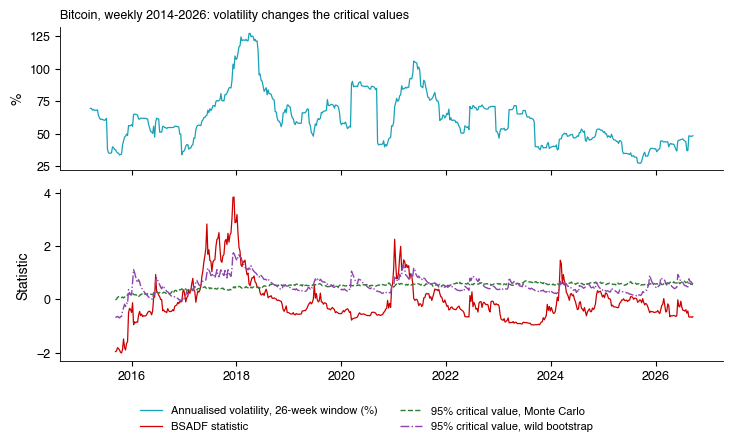

(3.848666319133873,
 {'90': 2.011965367670432, '95': 2.2705159532859884, '99': 2.6910831812657494},
 2.8225047174576106,
 [{'start': '2017-04-28',
   'end': '2018-06-08',
   'n': 59,
   'change': 4.791899637668441},
  {'start': '2020-12-25',
   'end': '2021-05-14',
   'n': 21,
   'change': 1.0223376264714514}],
 [{'start': '2017-05-05',
   'end': '2018-01-26',
   'n': 39,
   'change': 6.1821021192024235},
  {'start': '2020-12-25',
   'end': '2021-02-26',
   'n': 10,
   'change': 0.878781841154062}])

In [18]:
# Solution
def b3_btc_wild():
    """Bitcoin weekly: Monte Carlo critical values (Gaussian random walk) vs wild bootstrap."""
    y = np.log(price('btc', 'W'))
    o = run_psy(y, wild=True)
    idx = o['idx']
    dy = np.diff(y.values)
    vol = pd.Series(dy, index=idx).rolling(26).std() * np.sqrt(52)
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.0), sharex=True, gridspec_kw=dict(height_ratios=[1, 1.2]))
    axes[0].plot(vol.index, 100 * vol.values, color=Teal, lw=0.9, label='Annualised volatility, 26-week window (%)')
    axes[0].set_ylabel('%')
    axes[1].plot(idx, o['res']['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(idx, o['cv']['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value, Monte Carlo')
    axes[1].plot(idx, o['wild']['bsadf95'], color=Purple, lw=1.0, ls='-.', label='95% critical value, wild bootstrap')
    axes[1].set_ylabel('Statistic')
    axes[0].set_title('Bitcoin, weekly 2014-2026: volatility changes the critical values', fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_sem_btc_wild')
    s = summarise(o, y)
    s['vol_first'] = float(vol.dropna().iloc[:52].mean())
    s['vol_last'] = float(vol.dropna().iloc[-52:].mean())
    s['wild_bs_max'] = float(np.nanmax(o['wild']['bsadf95']))
    s['mc_bs_max'] = float(np.nanmax(o['cv']['bsadf95']))
    return s


b3 = b3_btc_wild()
(b3['gsadf'], b3['cv_gsadf'], b3['cv_gsadf_wild'], b3['episodes'], b3['episodes_wild'])

### B4. The Bucharest Stock Exchange [Proposed]

- BET monthly and BET-FI weekly; Monte Carlo and wild bootstrap. Model: B1, B3.
- Interpretation:
  - was 2003–2007 explosive in real time?
  - is the current rise explosive?

In [ ]:
# Your code here


### B5. How much does the critical time depend on the window? [Solved]

- Bitcoin, windows ending on 15 November 2017 with different starts; distribution of $t_c$.
- Interpretation: would you trust a single $t_c$ reported without its window?

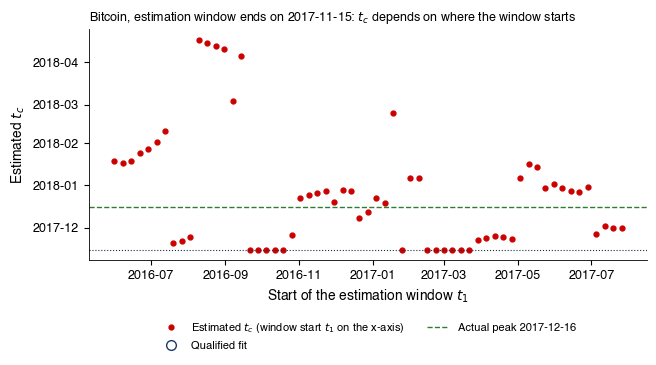

{'n': 61,
 't2': '2017-11-15',
 'peak': '2017-12-16',
 'tc_min': '2017-11-15',
 'tc_max': '2018-04-17',
 'tc_med': '2017-12-23',
 'iqr_days': 53.0,
 'share_q': 0.0,
 'share_bound': 0.4262295081967213,
 'share_30': 0.5573770491803278,
 'med_err': 7.0}

In [20]:
# Solution
def b5_tc_windows(t2='2017-11-15', starts=('2016-06-01', '2017-08-01')):
    """LPPLS on Bitcoin with a fixed t2 and a moving window start t1 (weekly): the distribution of tc."""
    p = price('btc', 'D')
    rows = []
    for t1 in pd.date_range(starts[0], starts[1], freq='7D'):
        w = p.loc[t1:t2]
        f = lppls_fit(yrs(w.index), np.log(w.values))
        rows.append(dict(t1=w.index[0], tc=todate(f['tc']), m=f['m'], w=f['w'], q=lppls_qualified(f),
                         at_bound=bool(f['m'] <= 0.002 or f['m'] >= 0.998 or f['w'] <= 1.01 or f['w'] >= 49.9)))
    d = pd.DataFrame(rows)
    pk = p.loc['2017'].idxmax()
    err = (d['tc'] - pk).dt.days
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(d['t1'], d['tc'], 'o', color=IDAred, ms=3.5, label='Estimated $t_c$ (window start $t_1$ on the x-axis)')
    ax.plot(d.loc[d['q'], 't1'], d.loc[d['q'], 'tc'], 'o', mfc='none', mec=MainBlue, ms=7, label='Qualified fit')
    ax.axhline(pk, color=Forest, ls='--', lw=1.0, label=f'Actual peak {pk.date()}')
    ax.axhline(pd.Timestamp(t2), color=Gray, ls=':', lw=0.8)
    ax.set_xlabel('Start of the estimation window $t_1$')
    ax.set_ylabel('Estimated $t_c$')
    ax.set_title(f'Bitcoin, estimation window ends on {t2}: $t_c$ depends on where the window starts', fontsize=9, loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch17_sem_tc_windows')
    return dict(n=int(len(d)), t2=t2, peak=d2s(pk), tc_min=d2s(d['tc'].min()), tc_max=d2s(d['tc'].max()),
                tc_med=d2s(d['tc'].sort_values().iloc[len(d) // 2]), iqr_days=float(np.subtract(*np.percentile(err, [75, 25]))),
                share_q=float(d['q'].mean()), share_bound=float(d['at_bound'].mean()),
                share_30=float((err.abs() <= 30).mean()), med_err=float(err.median()))


b5_tc_windows()

### B6. Does the confidence indicator beat chance? [Proposed]

- Nasdaq 100 indicator from 1997, dates about 7 calendar days apart; signal: indicator > 0; outcome: a close at least 20% below the signal-date close within 90 **calendar** days; only dates whose 90 days are observed.
- Circular block bootstrap of the dates (block of 90 days = 13 dates, 9 999 replications in the slides); Newey–West regression with 13 lags.
- Power: two equal groups, $p_0 = \hat p_{\text{off}}$, $p_1 = p_0 + 10$ points, 5% two-sided, power 80%: independent observations per group, then dependent dates per group and in total with the design effect. Model: B5, B3.
- Interpretation:
  - would it have helped an investor in 2000?
  - is absence of evidence here evidence of no information?

In [ ]:
# Your code here


### B7. Markov switching on the S&P 500 [Solved]

- Weekly log returns 1990–2026, two regimes; filtered vs smoothed probabilities.
- Interpretation:
  - is the turbulent mean significantly negative?
  - why is the LR test non-standard?

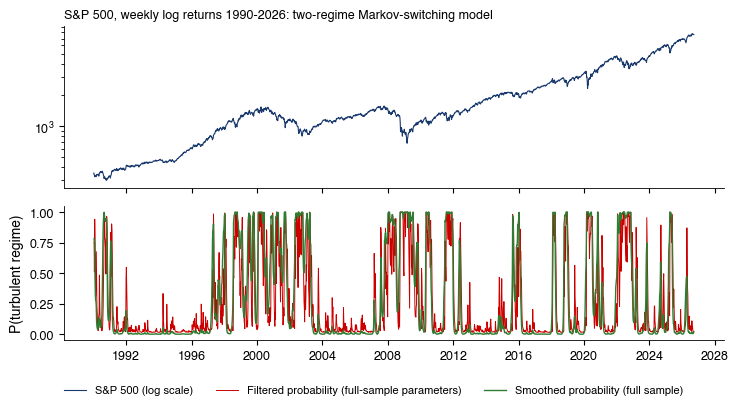

{'n': 1915,
 'start': '1990-01-12',
 'end': '2026-09-18',
 'llf': -4069.9788187586073,
 'aic': 8151.957637517215,
 'bic': 8185.302474926903,
 'calm': {'mu': 0.32236877543754466,
  'mu_se': 0.043417246574547076,
  'sd': 1.4869522241343698,
  'stay': 0.9737331248887896,
  'dur': 38.070763871459214,
  'share': 0.7266371440119535},
 'turb': {'mu': -0.26869365621891866,
  'mu_se': 0.1721395859970641,
  'sd': 3.674259622314027,
  'stay': 0.9306315309071383,
  'dur': 14.415771503639897,
  'share': 0.2733628559880472},
 'first_dotcom': '2000-01-28',
 'first_gfc': '2008-10-03',
 'first_covid': '2020-02-28',
 'share_turb_smoothed': 0.2558746736292428,
 'agree': 0.9007832898172323,
 'llf1': -4326.01626649381,
 'lr': 512.074895470405}

In [22]:
# Solution
def b7_ms_sp():
    """Two-regime Markov switching on the weekly S&P 500, 1990-2026."""
    p, r, res, hi = ms_fit('sp500', '1990-01-01')
    out = ms_summary(res, hi, r)
    fp = res.filtered_marginal_probabilities[hi]
    sp = res.smoothed_marginal_probabilities[hi]
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 3.8), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    axes[0].plot(p.index, p.values, color=MainBlue, lw=0.8, label='S&P 500 (log scale)')
    axes[0].set_yscale('log')
    axes[1].plot(fp.index, fp.values, color=IDAred, lw=0.7, label='Filtered probability (full-sample parameters)')
    axes[1].plot(sp.index, sp.values, color=Forest, lw=1.0, label='Smoothed probability (full sample)')
    axes[1].set_ylabel('P(turbulent regime)')
    axes[0].set_title('S&P 500, weekly log returns 1990-2026: two-regime Markov-switching model', fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=3, y=0.0)
    save_fig('ch17_sem_ms_sp')
    for tag, a, b in [('dotcom', '2000-01-01', '2000-12-31'), ('gfc', '2008-09-01', '2008-12-31'), ('covid', '2020-02-15', '2020-04-30')]:
        x = fp.loc[a:b]
        out[f'first_{tag}'] = d2s(x[x > 0.5].index[0]) if (x > 0.5).any() else None
    ssp = sp > 0.5
    out['share_turb_smoothed'] = float(ssp.mean())
    out['agree'] = float(((fp > 0.5) == ssp).mean())
    # one regime: the same mean and variance
    ll1 = float(stats.norm.logpdf(r, r.mean(), r.std(ddof=0)).sum())
    out['llf1'] = ll1
    out['lr'] = 2 * (out['llf'] - ll1)
    return out


b7_ms_sp()

### B8. Bitcoin: two or three regimes? [Proposed]

- AIC and BIC; parametric-bootstrap LR test of two vs three regimes (the slides use 199 replications). Model: B7.
- Interpretation: why is chi-square the wrong reference distribution?

In [ ]:
# Your code here


### B9. Size of GSADF under a volatility shift [Solved]

- Random walks with the volatility tripling at $T/2$; rejection rates with Monte Carlo and wild bootstrap critical values (the slides use 1,000 paths and 199 bootstrap replications).
- Interpretation: which critical value would you trust for Bitcoin?

In [25]:
SCENARIOS = {'iid': 'Constant volatility', 'up': 'Volatility triples at T/2', 'down': 'Volatility falls to one third at T/2', 'garch': 'GARCH(1,1), alpha = 0.10, beta = 0.88'}
SIZE_T, SIZE_B = 400, 99


def null_shocks(kind, T, rng):
    """Shocks with unconditional variance 1 (i.i.d.) or with changing volatility."""
    z = rng.standard_normal(T)
    if kind == 'iid':
        return z
    if kind == 'up':
        return z * np.where(np.arange(T) < T // 2, 1.0, 3.0)
    if kind == 'down':
        return z * np.where(np.arange(T) < T // 2, 3.0, 1.0)
    if kind == 'garch':                               # sigma2_t = w + a e_{t-1}^2 + b sigma2_{t-1}, unconditional variance 1
        a, b = 0.10, 0.88
        w = 1 - a - b
        zz = rng.standard_normal(T + 500)
        e = np.empty(T + 500)
        s2 = 1.0
        for t in range(T + 500):
            e[t] = np.sqrt(s2) * zz[t]
            s2 = w + a * e[t] ** 2 + b * s2
        return e[500:]
    raise ValueError(kind)


def size_demo(kind, N=200):
    w0, _ = min_window(SIZE_T)
    cv = psy_cv(SIZE_T, w0, 1000, SEED + 1)['gsadf']['95']   # independent of the evaluation paths
    rng = np.random.default_rng(SEED)
    rej_mc = rej_w = 0
    for i in range(N):
        y = np.concatenate([[0.0], np.cumsum(1.0 / SIZE_T + null_shocks(kind, SIZE_T, rng))])
        g_ = psy(y)['gsadf']
        rej_mc += g_ > cv
        rej_w += g_ > wild_cv(y, w0, SIZE_B, seed=i)['gsadf95']
    return dict(kind=kind, size_mc=rej_mc / N, size_wild=rej_w / N)


pd.DataFrame([size_demo('iid'), size_demo('up')])

,kind,size_mc,size_wild
0,iid,0.050,0.045
1,up,0.335,0.075


### B10. Size under GARCH volatility [Proposed]

- Two separate null models: GARCH(1,1) with $\alpha = 0.10$, $\beta = 0.88$; and, separately, a random walk whose volatility falls from 3 to 1 at $T/2$. Model: B9.
- Interpretation: why does a fall in volatility not create false bubbles?

In [ ]:
# Your code here


## Part C — open questions

### C1. Is there an AI bubble? [Proposed]

- NVIDIA and the Nasdaq 100 today vs Cisco and the Nasdaq 100 in the dot-com episode: GSADF/BSADF with Monte Carlo and wild bootstrap critical values, two-year run-ups, drawdowns, the LPPLS confidence indicator today.
- Which earnings or sales data would you add to separate a bubble from explosive fundamentals?

In [ ]:
# Your code here


### C2. Critique an AI answer [Proposed]

- The AI answer on the slides: SADF code for the S&P 500 log price-dividend ratio and an LPPLS crash date.
- Find the three errors, say how you would detect each one without knowing the answer, write the corrected code (simulated critical values, BSADF on windows that end at $t$, episodes of at least $\lceil \ln T \rceil$ months) and log the errors in `AI_ERRORS.md`. Model: A3, B1, B5.

In [ ]:
# Your code here

### C3. Does volume lead prices in a speculative boom? [Proposed]

- Monthly Case-Shiller U.S. National Home Price Index and new one-family houses sold (FRED), 1990–2011: the implied correlation of the demeaned log price with sales lagged $k = -12, \dots, 48$ months, block-bootstrap CIs and the dates of the quiet phase. Model: B3; see also B6.

In [ ]:
# Your code here